# 100-Packet Scenario: FLOODING vs DSDV Comparison

This notebook analyzes the performance of FLOODING vs DSDV routing protocols in 100-packet transmission scenarios.

**Metrics analyzed:**
- Packet Delivery Ratio (PDR) across different mobile speeds
- Average Latency
- Node participation

## 1. Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore the Dataset

In [2]:
# Load the CSV file
csv_path = '100packet_comparison.csv'
df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()

Dataset loaded successfully!

Shape: (11, 9)

Columns: ['routing_mode', 'mobile_speed', 'initial_distance', 'timestamp', 'total_sent', 'total_delivered', 'pdr_pct', 'avg_latency_s', 'unique_nodes']

First few rows:


,routing_mode,mobile_speed,initial_distance,timestamp,total_sent,total_delivered,pdr_pct,avg_latency_s,unique_nodes
0,FLOODING,7mps,unknownm,20/02/2026 02:53,100,100,100,1.7208,22
1,FLOODING,7mps,unknownm,20/02/2026 03:00,100,100,100,1.7194,22
2,FLOODING,7mps,unknownm,20/02/2026 03:03,100,100,100,1.7121,22
3,FLOODING,11mps,unknownm,20/02/2026 09:03,100,100,100,1.7217,22
4,FLOODING,11mps,unknownm,20/02/2026 09:04,100,100,100,1.7121,22


## 3. Data Preprocessing

In [3]:
# Extract numeric speed values from mobile_speed column (e.g., "7mps" -> 7)
df['speed_numeric'] = df['mobile_speed'].str.extract(r'(\d+)').astype(int)

print("Data preprocessing complete!")
print(f"\nUnique speeds: {sorted(df['speed_numeric'].unique())}")
print(f"Routing modes: {df['routing_mode'].unique()}")
print(f"\nTotal runs: {len(df)}")

# Group by routing mode and speed to calculate mean and std (for multiple runs)
grouped = df.groupby(['routing_mode', 'speed_numeric']).agg({
    'pdr_pct': ['mean', 'std', 'count'],
    'avg_latency_s': ['mean', 'std'],
    'total_sent': 'mean',
    'total_delivered': 'mean',
    'unique_nodes': 'mean'
}).reset_index()

grouped.columns = ['routing_mode', 'speed_numeric', 'pdr_mean', 'pdr_std', 'run_count',
                   'latency_mean', 'latency_std', 'sent_mean', 'delivered_mean', 'nodes_mean']

# Handle NaN in std (when only 1 run per group)
grouped['pdr_std'] = grouped['pdr_std'].fillna(0)
grouped['latency_std'] = grouped['latency_std'].fillna(0)

print("\nAggregated data (mean ± std):")
grouped

Data preprocessing complete!

Unique speeds: [np.int64(7), np.int64(11)]
Routing modes: ['FLOODING' 'DSDV']

Total runs: 11

Aggregated data (mean ± std):


,routing_mode,speed_numeric,pdr_mean,pdr_std,run_count,latency_mean,latency_std,sent_mean,delivered_mean,nodes_mean
0,DSDV,7,89.666667,1.527525,3,1.712100,0.000000,100.0,89.666667,22.0
1,DSDV,11,89.000000,5.656854,2,1.713550,0.002051,100.0,89.000000,22.0
2,FLOODING,7,100.000000,0.000000,3,1.717433,0.004672,100.0,100.000000,22.0
3,FLOODING,11,100.000000,0.000000,3,1.718767,0.005787,100.0,100.000000,22.0


## 4. Plot 1: PDR Comparison (Grouped Bar Chart)

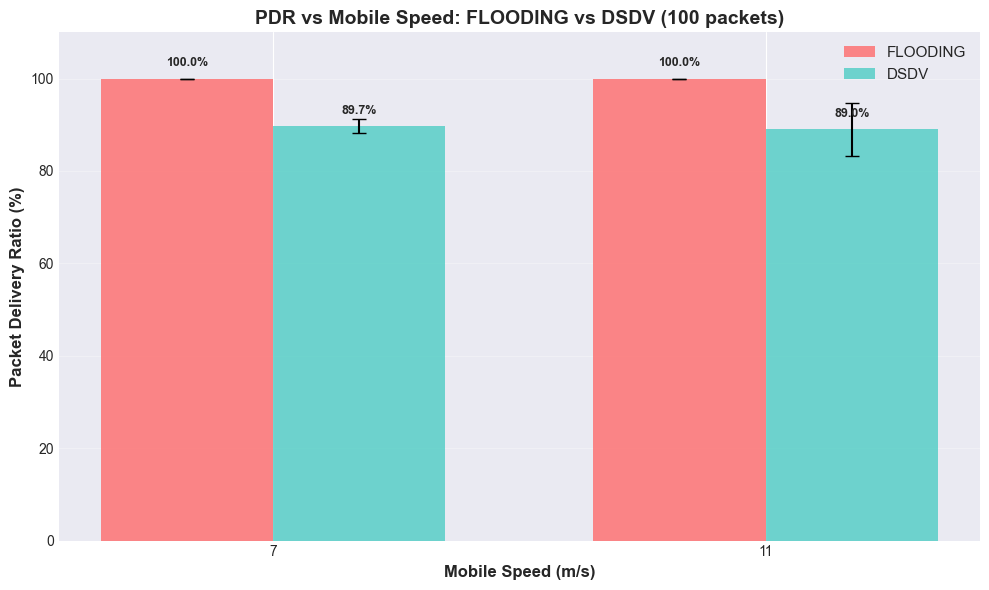

PDR comparison plot saved!


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for grouped bar chart
flooding_data = grouped[grouped['routing_mode'] == 'FLOODING']
dsdv_data = grouped[grouped['routing_mode'] == 'DSDV']

speeds = sorted(grouped['speed_numeric'].unique())
x = np.arange(len(speeds))
width = 0.35

# Get values for bars
flooding_values = [flooding_data[flooding_data['speed_numeric'] == s]['pdr_mean'].values[0] if len(flooding_data[flooding_data['speed_numeric'] == s]) > 0 else 0 for s in speeds]
dsdv_values = [dsdv_data[dsdv_data['speed_numeric'] == s]['pdr_mean'].values[0] if len(dsdv_data[dsdv_data['speed_numeric'] == s]) > 0 else 0 for s in speeds]

# Get standard deviations for error bars
flooding_stds = [flooding_data[flooding_data['speed_numeric'] == s]['pdr_std'].values[0] if len(flooding_data[flooding_data['speed_numeric'] == s]) > 0 else 0 for s in speeds]
dsdv_stds = [dsdv_data[dsdv_data['speed_numeric'] == s]['pdr_std'].values[0] if len(dsdv_data[dsdv_data['speed_numeric'] == s]) > 0 else 0 for s in speeds]

# Create bars with error bars
bars1 = ax.bar(x - width/2, flooding_values, width, label='FLOODING', color='#FF6B6B', alpha=0.8, yerr=flooding_stds, capsize=5)
bars2 = ax.bar(x + width/2, dsdv_values, width, label='DSDV', color='#4ECDC4', alpha=0.8, yerr=dsdv_stds, capsize=5)

# Add percentage labels on top of bars
for i, (bar, value) in enumerate(zip(bars1, flooding_values)):
    if value > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{value:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

for i, (bar, value) in enumerate(zip(bars2, dsdv_values)):
    if value > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{value:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize plot
ax.set_xlabel('Mobile Speed (m/s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Packet Delivery Ratio (%)', fontsize=12, fontweight='bold')
ax.set_title('PDR vs Mobile Speed: FLOODING vs DSDV (100 packets)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{s}' for s in speeds])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('pdr_comparison_100packets.png', dpi=300, bbox_inches='tight')
plt.show()

print("PDR comparison plot saved!")

## 5. Plot 2: Average Latency Comparison

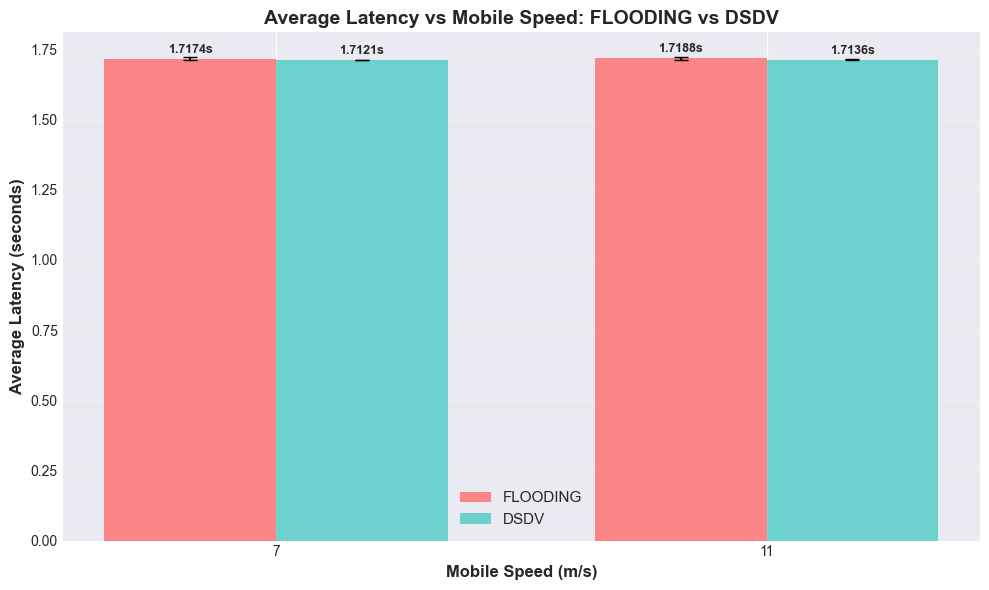

Latency comparison plot saved!


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for grouped bar chart
speeds = sorted(grouped['speed_numeric'].unique())
x = np.arange(len(speeds))
width = 0.35

# Get values for bars
flooding_latency = [flooding_data[flooding_data['speed_numeric'] == s]['latency_mean'].values[0] if len(flooding_data[flooding_data['speed_numeric'] == s]) > 0 else 0 for s in speeds]
dsdv_latency = [dsdv_data[dsdv_data['speed_numeric'] == s]['latency_mean'].values[0] if len(dsdv_data[dsdv_data['speed_numeric'] == s]) > 0 else 0 for s in speeds]

# Get standard deviations
flooding_lat_stds = [flooding_data[flooding_data['speed_numeric'] == s]['latency_std'].values[0] if len(flooding_data[flooding_data['speed_numeric'] == s]) > 0 else 0 for s in speeds]
dsdv_lat_stds = [dsdv_data[dsdv_data['speed_numeric'] == s]['latency_std'].values[0] if len(dsdv_data[dsdv_data['speed_numeric'] == s]) > 0 else 0 for s in speeds]

# Create bars
bars1 = ax.bar(x - width/2, flooding_latency, width, label='FLOODING', color='#FF6B6B', alpha=0.8, yerr=flooding_lat_stds, capsize=5)
bars2 = ax.bar(x + width/2, dsdv_latency, width, label='DSDV', color='#4ECDC4', alpha=0.8, yerr=dsdv_lat_stds, capsize=5)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars1, flooding_latency)):
    if value > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.4f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

for i, (bar, value) in enumerate(zip(bars2, dsdv_latency)):
    if value > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.4f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize plot
ax.set_xlabel('Mobile Speed (m/s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Latency (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Average Latency vs Mobile Speed: FLOODING vs DSDV', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{s}' for s in speeds])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('latency_comparison_100packets.png', dpi=300, bbox_inches='tight')
plt.show()

print("Latency comparison plot saved!")

## 6. Individual Run Analysis (Scatter Plot)

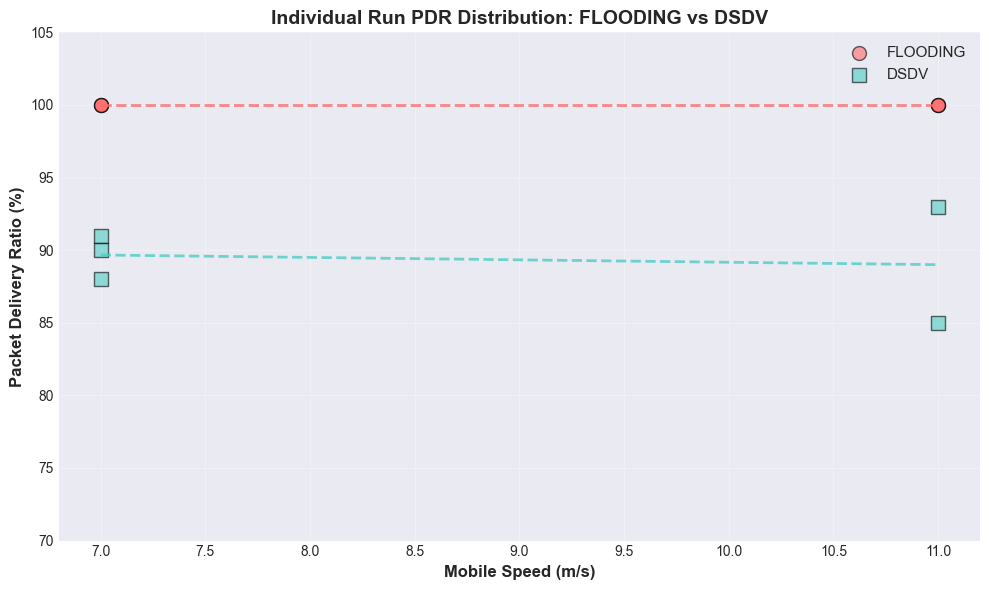

Scatter plot saved!


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot individual runs as scatter points
for mode, color, marker in [('FLOODING', '#FF6B6B', 'o'), ('DSDV', '#4ECDC4', 's')]:
    mode_data = df[df['routing_mode'] == mode]
    ax.scatter(mode_data['speed_numeric'], mode_data['pdr_pct'], 
               s=100, alpha=0.6, color=color, marker=marker, label=mode, edgecolors='black', linewidths=1)

# Add mean lines
for mode, color in [('FLOODING', '#FF6B6B'), ('DSDV', '#4ECDC4')]:
    mode_grouped = grouped[grouped['routing_mode'] == mode]
    ax.plot(mode_grouped['speed_numeric'], mode_grouped['pdr_mean'], 
            color=color, linewidth=2, linestyle='--', alpha=0.8)

# Customize plot
ax.set_xlabel('Mobile Speed (m/s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Packet Delivery Ratio (%)', fontsize=12, fontweight='bold')
ax.set_title('Individual Run PDR Distribution: FLOODING vs DSDV', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(70, 105)

plt.tight_layout()
plt.savefig('pdr_scatter_100packets.png', dpi=300, bbox_inches='tight')
plt.show()

print("Scatter plot saved!")

## 7. Summary Statistics

In [7]:
print("="*80)
print("SUMMARY STATISTICS BY ROUTING MODE")
print("="*80)

for mode in ['FLOODING', 'DSDV']:
    mode_df = df[df['routing_mode'] == mode]
    print(f"\n{mode}:")
    print(f"  Number of runs: {len(mode_df)}")
    print(f"  PDR: {mode_df['pdr_pct'].mean():.2f}% ± {mode_df['pdr_pct'].std():.2f}%")
    print(f"  Latency: {mode_df['avg_latency_s'].mean():.4f}s ± {mode_df['avg_latency_s'].std():.4f}s")
    print(f"  Avg Delivered: {mode_df['total_delivered'].mean():.1f} / {mode_df['total_sent'].mean():.0f}")
    print(f"  Unique Nodes: {mode_df['unique_nodes'].mean():.1f}")

print("\n" + "="*80)
print("COMPARISON BY SPEED")
print("="*80)

comparison_table = grouped[['routing_mode', 'speed_numeric', 'pdr_mean', 'pdr_std', 'run_count', 'latency_mean']].copy()
comparison_table.columns = ['Routing Mode', 'Speed (m/s)', 'PDR Mean (%)', 'PDR Std (%)', 'Runs', 'Latency (s)']
print("\n", comparison_table.to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

flooding_avg_pdr = df[df['routing_mode'] == 'FLOODING']['pdr_pct'].mean()
dsdv_avg_pdr = df[df['routing_mode'] == 'DSDV']['pdr_pct'].mean()
pdr_diff = flooding_avg_pdr - dsdv_avg_pdr

print(f"\n1. FLOODING achieves {pdr_diff:.2f}% higher PDR than DSDV on average")
print(f"2. FLOODING: {flooding_avg_pdr:.2f}% PDR (100% in {len(df[(df['routing_mode'] == 'FLOODING') & (df['pdr_pct'] == 100)])}/{len(df[df['routing_mode'] == 'FLOODING'])} runs)")
print(f"3. DSDV: {dsdv_avg_pdr:.2f}% PDR with {df[df['routing_mode'] == 'DSDV']['pdr_pct'].std():.2f}% standard deviation")

flooding_lat = df[df['routing_mode'] == 'FLOODING']['avg_latency_s'].mean()
dsdv_lat = df[df['routing_mode'] == 'DSDV']['avg_latency_s'].mean()
lat_diff = abs(flooding_lat - dsdv_lat)
print(f"4. Latency difference: {lat_diff*1000:.2f}ms (FLOODING: {flooding_lat:.4f}s, DSDV: {dsdv_lat:.4f}s)")

SUMMARY STATISTICS BY ROUTING MODE

FLOODING:
  Number of runs: 6
  PDR: 100.00% ± 0.00%
  Latency: 1.7181s ± 0.0048s
  Avg Delivered: 100.0 / 100
  Unique Nodes: 22.0

DSDV:
  Number of runs: 5
  PDR: 89.40% ± 3.05%
  Latency: 1.7127s ± 0.0013s
  Avg Delivered: 89.4 / 100
  Unique Nodes: 22.0

COMPARISON BY SPEED

 Routing Mode  Speed (m/s)  PDR Mean (%)  PDR Std (%)  Runs  Latency (s)
        DSDV            7     89.666667     1.527525     3     1.712100
        DSDV           11     89.000000     5.656854     2     1.713550
    FLOODING            7    100.000000     0.000000     3     1.717433
    FLOODING           11    100.000000     0.000000     3     1.718767

KEY INSIGHTS

1. FLOODING achieves 10.60% higher PDR than DSDV on average
2. FLOODING: 100.00% PDR (100% in 6/6 runs)
3. DSDV: 89.40% PDR with 3.05% standard deviation
4. Latency difference: 5.42ms (FLOODING: 1.7181s, DSDV: 1.7127s)


## Conclusion

All plots have been generated and saved to the current folder:
- `pdr_comparison_100packets.png` - PDR comparison bar chart
- `latency_comparison_100packets.png` - Latency comparison bar chart
- `pdr_scatter_100packets.png` - Individual run distribution

**Key Observations:**
- FLOODING shows consistently higher and more stable PDR across all mobile speeds
- DSDV exhibits more variation in PDR between runs
- Latency is comparable between both protocols
- Both protocols utilize similar number of nodes (22 on average)